### **Plastic Waste Detection using YOLOv8n (60 Epochs)**


This notebook demonstrates the training of a YOLOv8n model for 60 epochs to evaluate the impact of extended training on plastic waste detection performance using the Trash-ICRA19 dataset.






The objective of this work is to evaluate the impact of increasing training epochs on the performance of an object detection model. Specifically, this study uses the YOLOv8n model to detect plastic waste in underwater images using the Trash-ICRA19 dataset. The aim is to compare a baseline model trained for 30 epochs with an enhanced model trained for 60 epochs, and analyse whether longer training improves detection accuracy, precision, recall, and overall performance.

## Methodology

This project follows a structured approach to train and evaluate an object detection model using the YOLOv8n architecture. First, the Trash-ICRA19 dataset was prepared and converted into YOLO format by organising images and labels into training, validation, and testing sets. The annotation format was converted from XML to YOLO TXT format to ensure compatibility with the model.

Next, a pretrained YOLOv8n model was loaded to apply transfer learning. The model was then trained for 60 epochs using the prepared dataset. The training process allowed the model to learn object features such as shape, size, and background patterns from the images.

After training, the model was evaluated using validation data to calculate performance metrics, including precision, recall, mAP50, and mAP50-95. These metrics were used to measure the accuracy and effectiveness of the model.

Finally, the trained model was used to perform predictions on test images. The outputs were analysed by comparing original images with predicted results, including bounding boxes, class labels, and confidence scores. The results were then compared with the baseline model to determine the impact of increased training epochs.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading Pretrained Model

A pretrained YOLOv8n model is loaded as the base model. This allows the use of transfer learning, which helps improve training efficiency and performance.

In [3]:
data_path = "/content/drive/MyDrive/Colab Notebook/trash_ICRA19/dataset"

In [8]:
!ls /content/drive/MyDrive/Colab/trash_ICRA19/dataset

README.txt  test  train  trash_ICRA19  val  videos_for_testing


In [9]:
!cat /content/drive/MyDrive/Colab/trash_ICRA19/dataset

cat: /content/drive/MyDrive/Colab/trash_ICRA19/dataset: Is a directory


In [10]:
!ls "/content/drive/MyDrive/Colab/trash_ICRA19/dataset/train/images"

bio0000_frame0000001.jpg  obj0228_frame0000033.jpg  obj1108_frame0000091.jpg
bio0000_frame0000002.jpg  obj0228_frame0000034.jpg  obj1108_frame0000093.jpg
bio0000_frame0000004.jpg  obj0228_frame0000035.jpg  obj1108_frame0000095.jpg
bio0000_frame0000006.jpg  obj0228_frame0000036.jpg  obj1108_frame0000126.jpg
bio0000_frame0000008.jpg  obj0228_frame0000037.jpg  obj1108_frame0000136.jpg
bio0000_frame0000010.jpg  obj0228_frame0000038.jpg  obj1108_frame0000141.jpg
bio0000_frame0000012.jpg  obj0228_frame0000039.jpg  obj1108_frame0000149.jpg
bio0000_frame0000014.jpg  obj0228_frame0000040.jpg  obj1108_frame0000161.jpg
bio0000_frame0000017.jpg  obj0228_frame0000041.jpg  obj1111_frame0000003.jpg
bio0000_frame0000019.jpg  obj0236_frame0000019.jpg  obj1111_frame0000010.jpg
bio0000_frame0000021.jpg  obj0236_frame0000020.jpg  obj1111_frame0000015.jpg
bio0000_frame0000023.jpg  obj0236_frame0000021.jpg  obj1111_frame0000018.jpg
bio0000_frame0000025.jpg  obj0236_frame0000022.jpg  obj1111_frame0000021.jpg

In [11]:
!ls "/content/drive/MyDrive/Colab/trash_ICRA19/dataset/train/labels" | head

bio0000_frame0000001.txt
bio0000_frame0000002.txt
bio0000_frame0000004.txt
bio0000_frame0000006.txt
bio0000_frame0000008.txt
bio0000_frame0000010.txt
bio0000_frame0000012.txt
bio0000_frame0000014.txt
bio0000_frame0000017.txt
bio0000_frame0000019.txt


## Dataset Preparation

In this step, the dataset path is defined and verified. The dataset is organised into training, validation, and testing sets in YOLO format to ensure compatibility with the model.

In [12]:
%%writefile "/content/drive/MyDrive/Colab/trash_ICRA19/data.yaml"
train: /content/drive/MyDrive/Colab/trash_ICRA19/dataset/train/images
val: /content/drive/MyDrive/Colab/trash_ICRA19/dataset/val/images
test: /content/drive/MyDrive/Colab/trash_ICRA19/dataset/test/images

nc: 3
names: ['plastic', 'bio', 'rov']

Overwriting /content/drive/MyDrive/Colab/trash_ICRA19/data.yaml


## Installing Required Libraries

In this step, the required Python library (Ultralytics) is installed to enable the use of the YOLOv8 model. This library provides tools for training, evaluating, and testing object detection models efficiently.

## Importing YOLO Model

This step imports the YOLOv8 model from the Ultralytics library. The YOLO model is a deep learning-based object detection algorithm used for object detection tasks.

## Model Training

The model is trained for 60 epochs using the prepared dataset. Increasing the number of epochs allows the model to learn patterns and features more effectively, improving detection performance.

In [13]:
!pip install ultralytics

from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/drive/MyDrive/Colab/trash_ICRA19/data.yaml",
    epochs=60,
    imgsz=640,
    batch=16,
    name="member2_60epochs_gpu"
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab/trash_ICRA19/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bdd8c3a7a40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

## Model Evaluation

After training, the model is evaluated using validation data. Performance metrics such as precision, recall, mAP50, and mAP50-95 are used to measure the effectiveness of the model.

In [15]:
!cp -r /content/runs/detect/member2_60epochs_gpu "/content/drive/MyDrive/Enhanced_training_Manan_60epochs_gpu"

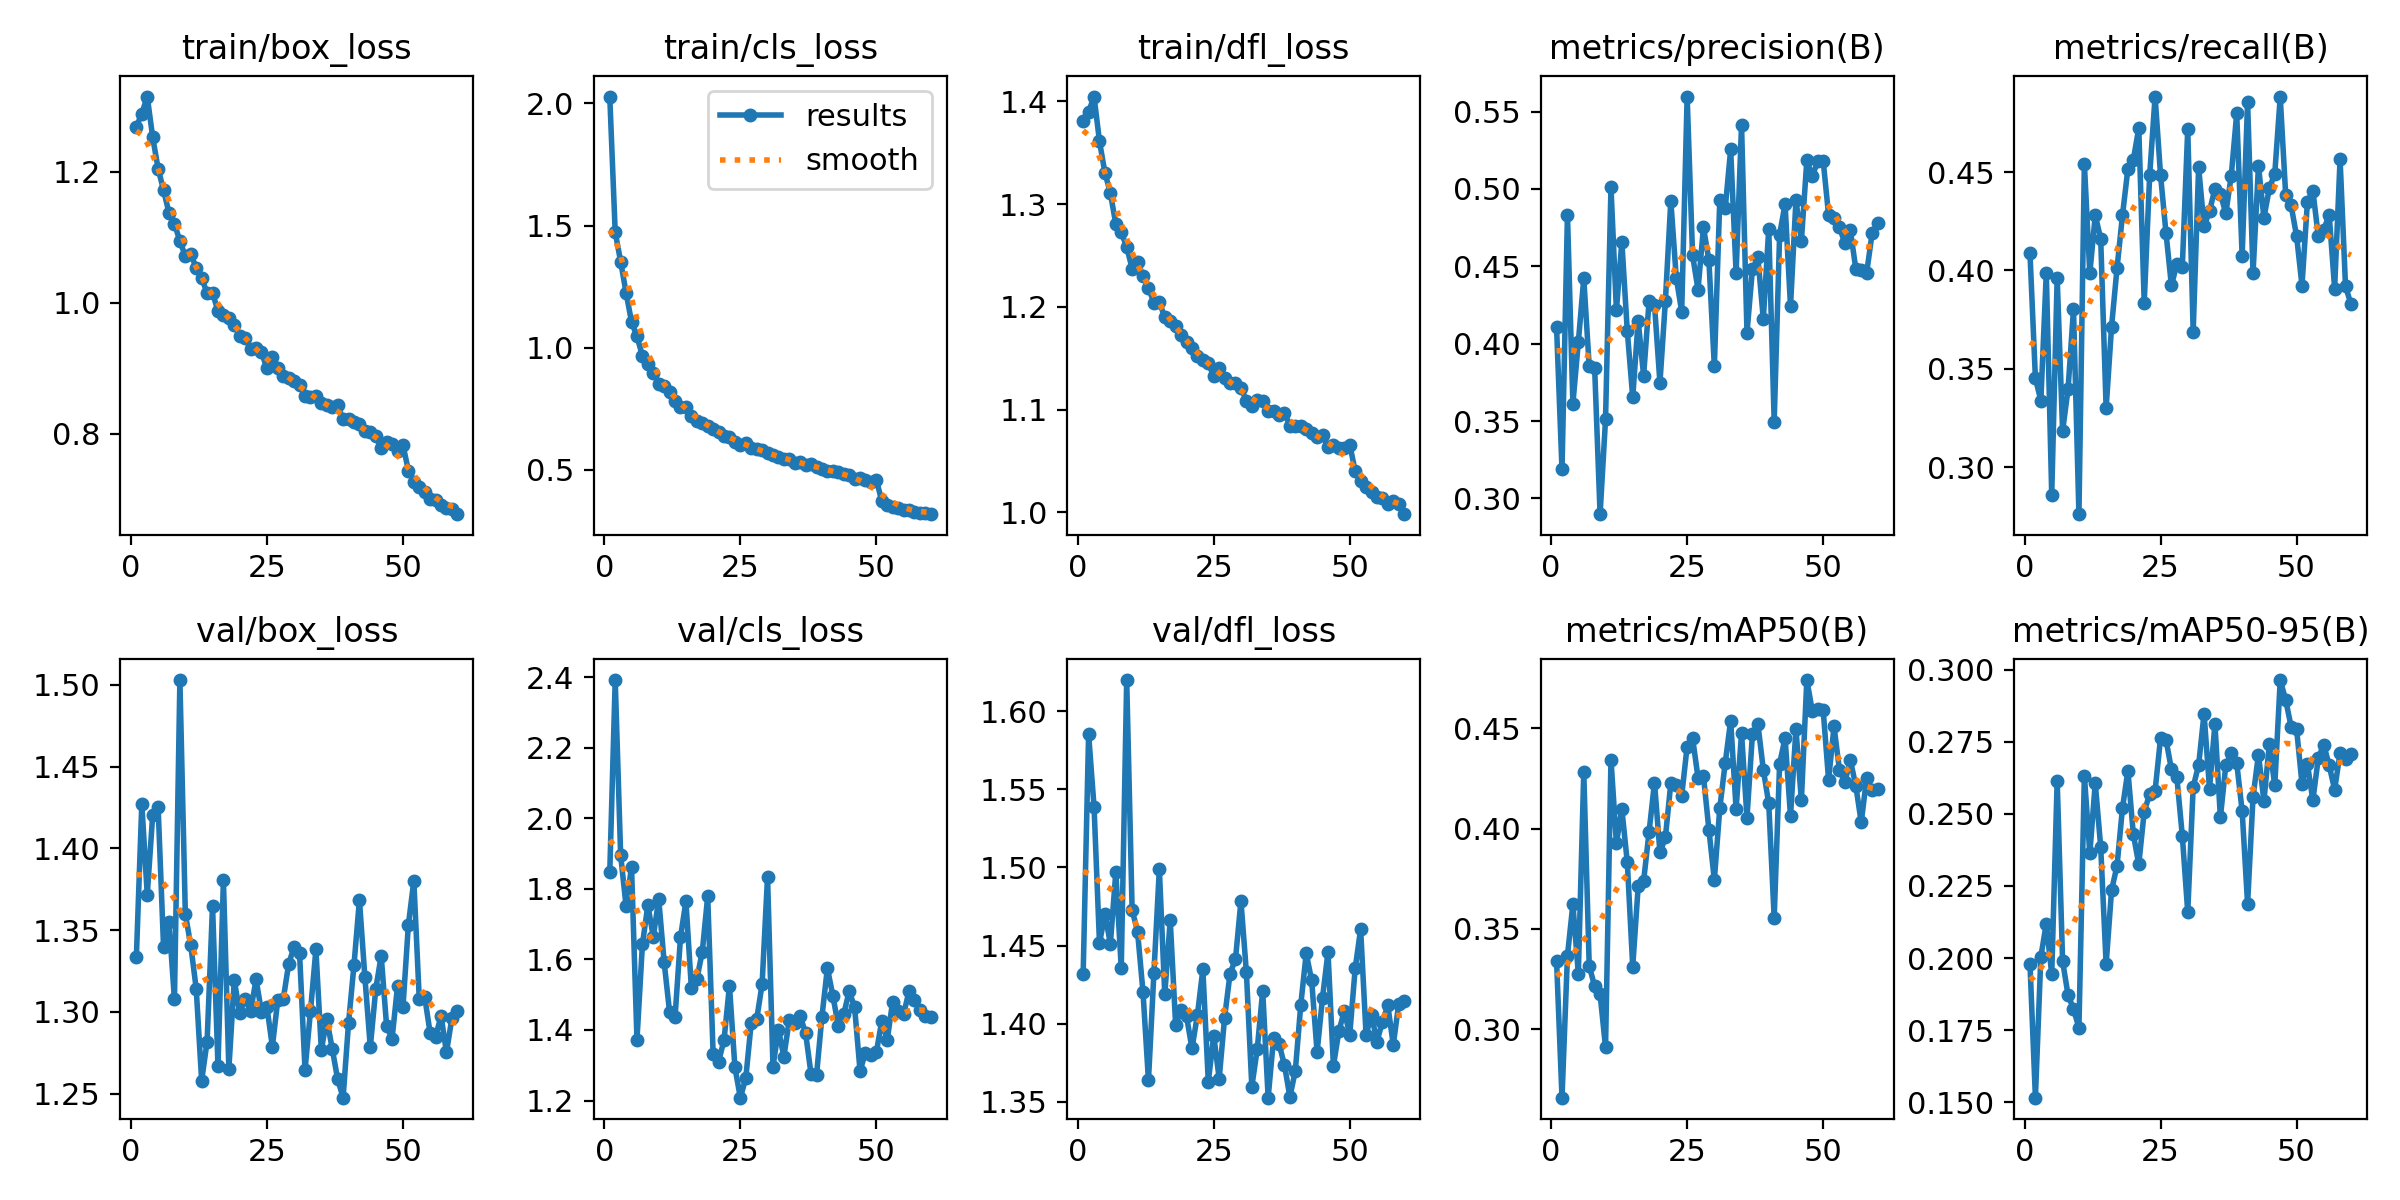

In [16]:
from IPython.display import Image
Image(filename="/content/runs/detect/member2_60epochs_gpu/results.png")

## Confusion Matrix

The confusion matrix shows how well the model classifies each object. Correct predictions appear on the diagonal, while incorrect predictions appear outside it. The model performs better on common classes like “plastic” and struggles with less frequent classes such as “bio.”

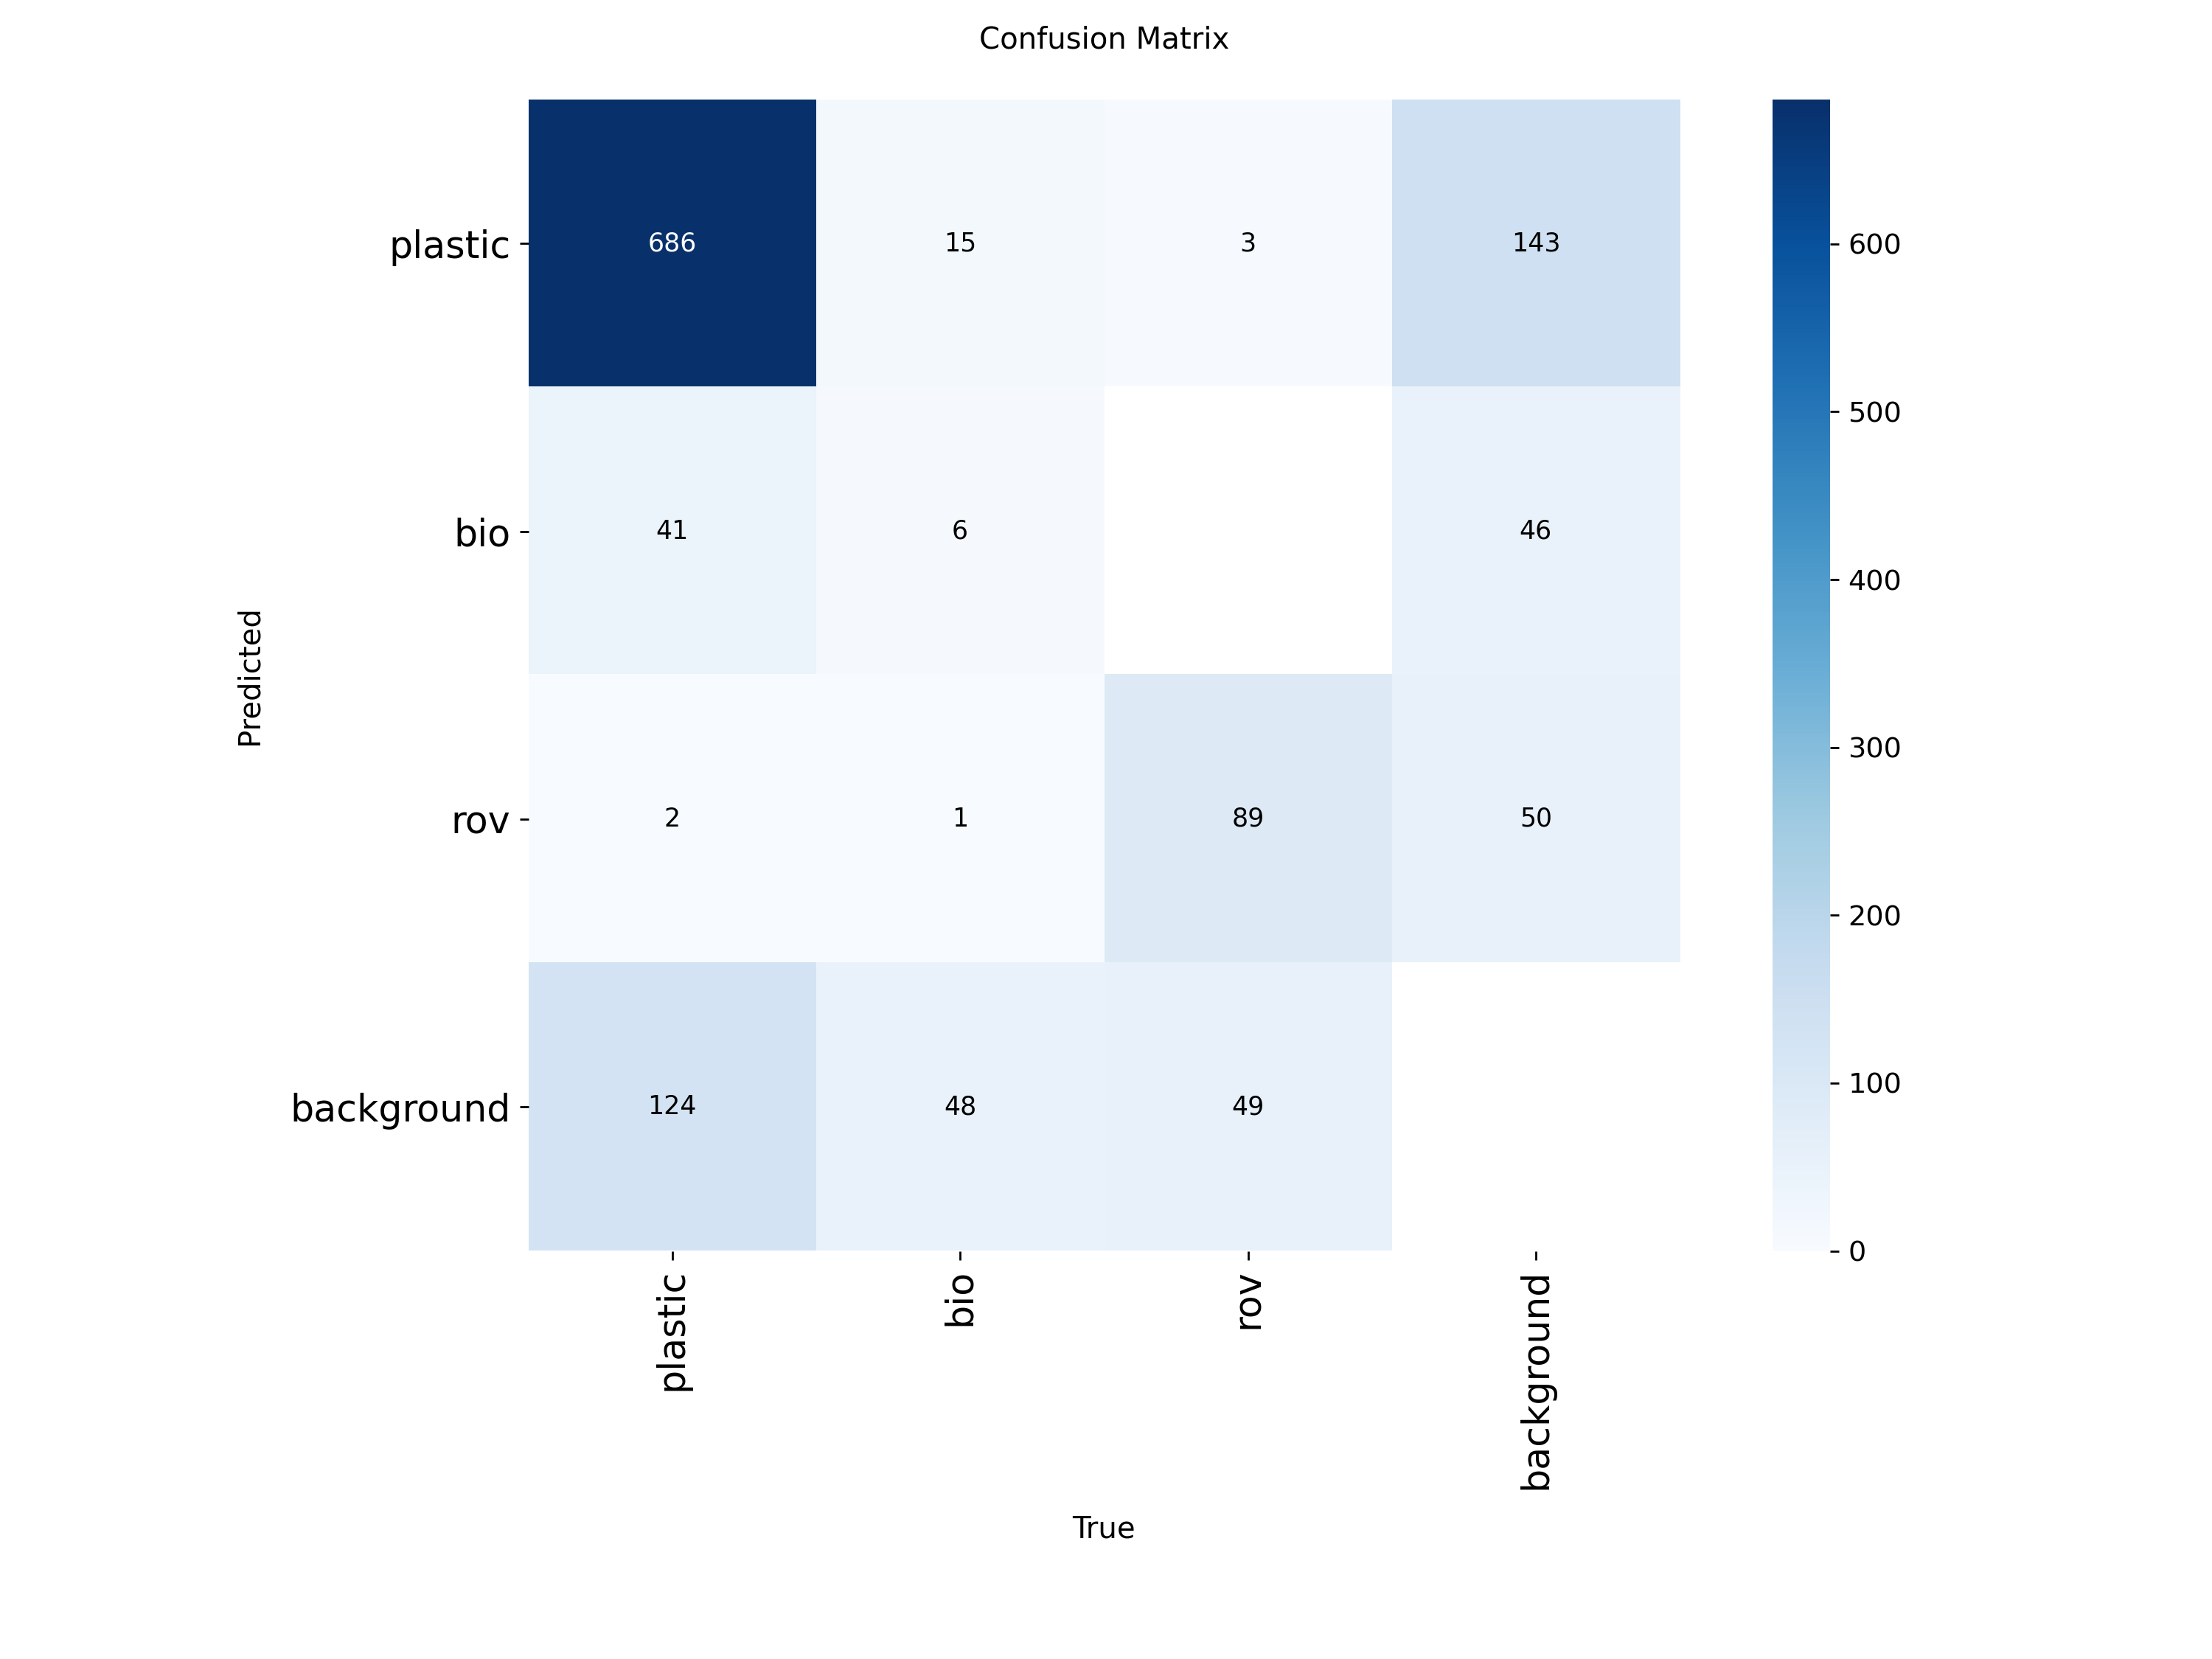

In [17]:
Image(filename="/content/runs/detect/member2_60epochs_gpu/confusion_matrix.png")

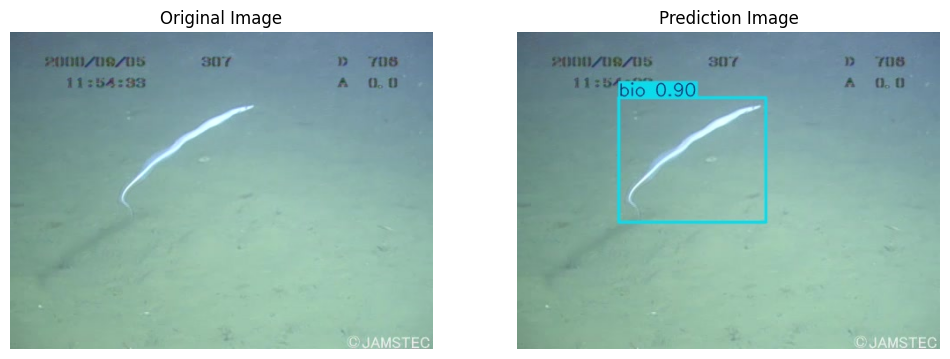

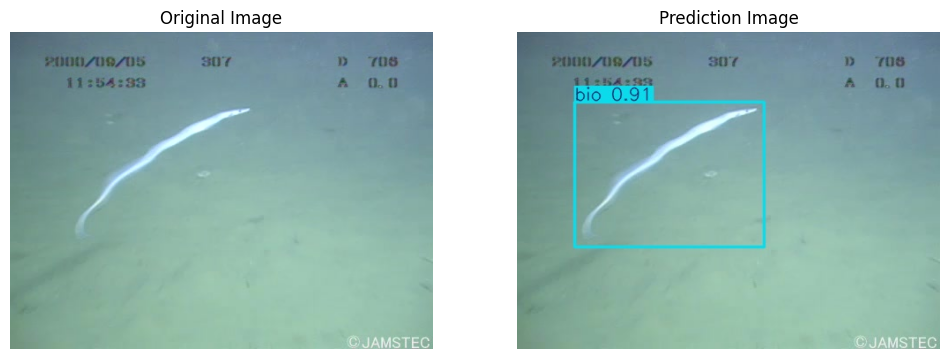

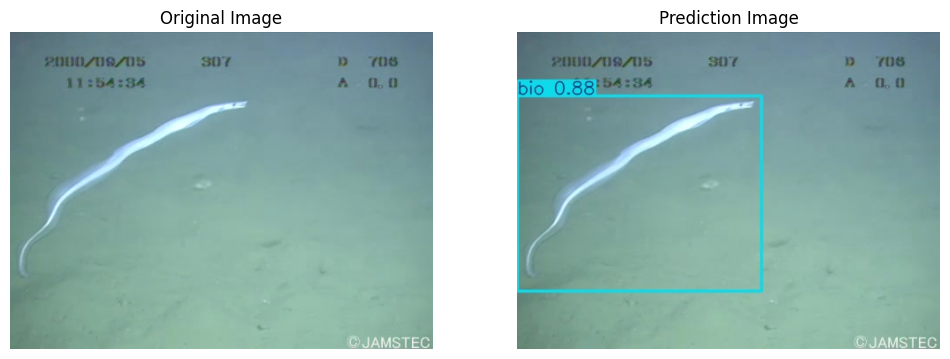

In [19]:
import os, glob
import matplotlib.pyplot as plt
from PIL import Image

originals = glob.glob("/content/drive/MyDrive/Colab/trash_ICRA19/dataset/test/images/*.jpg")[:3]
pred_folder = sorted(glob.glob("/content/runs/detect/predict*"))[-1]

for img_path in originals:
    pred_path = os.path.join(pred_folder, os.path.basename(img_path))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(Image.open(img_path))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(Image.open(pred_path))
    plt.title("Prediction Image")
    plt.axis("off")

    plt.show()

In [20]:
import glob

# get 3 test images
images = glob.glob("/content/drive/MyDrive/Colab/trash_ICRA19/dataset/test/images/*.jpg")[:3]

from ultralytics import YOLO
model = YOLO("/content/runs/detect/member2_60epochs_gpu/weights/best.pt")

model.predict(
    source=images,   # only 3 images
    save=True,
    conf=0.25
)


0: 480x640 1 bio, 12.8ms
1: 480x640 1 bio, 12.8ms
2: 480x640 1 bio, 12.8ms
Speed: 2.3ms preprocess, 12.8ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict-2


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'plastic', 1: 'bio', 2: 'rov'}
 obb: None
 orig_img: array([[[ 93,  79,  56],
         [ 93,  79,  56],
         [ 93,  79,  56],
         ...,
         [118,  95,  69],
         [116,  93,  67],
         [115,  92,  66]],
 
        [[110,  96,  73],
         [110,  96,  73],
         [110,  96,  73],
         ...,
         [136, 113,  87],
         [135, 112,  86],
         [134, 111,  85]],
 
        [[113,  99,  76],
         [113,  99,  76],
         [113,  99,  76],
         ...,
         [139, 116,  90],
         [138, 115,  89],
         [137, 114,  88]],
 
        ...,
 
        [[131, 153, 118],
         [128, 150, 115],
         [127, 149, 114],
         ...,
         [155, 176, 131],
         [155, 175, 133],
         [159, 178, 139]],
 
        [[128, 150, 115],
         [126, 148, 113],
         [126, 148, 113],
         ..

## Result Visualisation

This step visualises the detection results to analyse how well the model identifies waste objects in real images.

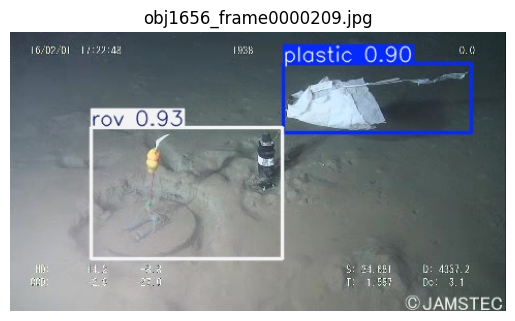

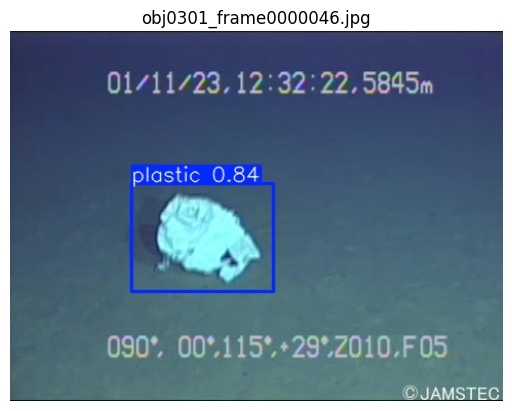

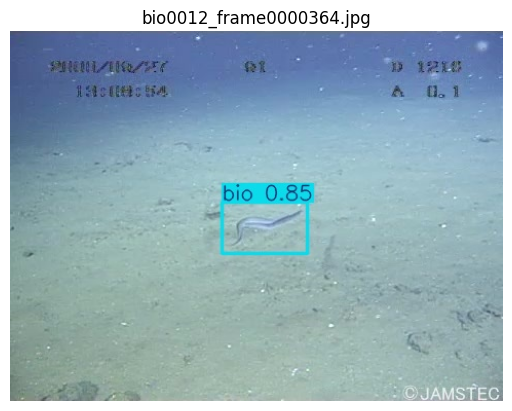

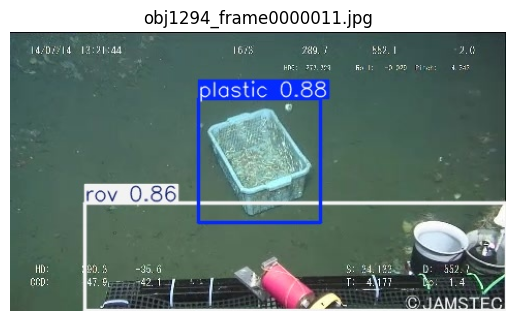

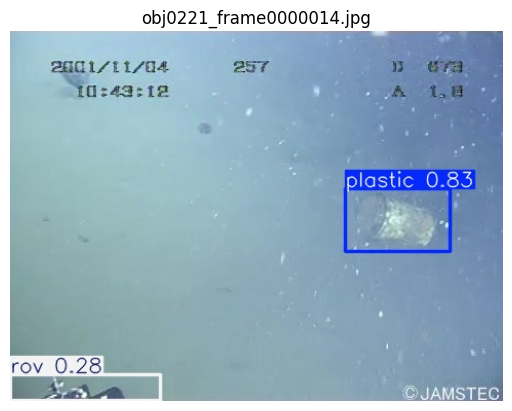

In [21]:
from PIL import Image
import matplotlib.pyplot as plt
import os

folder = "/content/runs/detect/predict"

images = os.listdir(folder)[:5]  # show first 3

for img_name in images:
    img_path = os.path.join(folder, img_name)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')
    plt.show()

## Challenges Faced

During the implementation, several challenges were encountered. The dataset initially required conversion from XML to YOLO format, which increased preprocessing time. Google Colab runtime resets caused loss of data and training progress. Additionally, limited GPU availability slowed down training. Some issues related to incorrect file paths and missing configuration files also interrupted the workflow.

## Analysis

The baseline model was trained for 30 epochs, while this model was trained for 60 epochs using the same YOLOv8n architecture and dataset. The baseline model achieved a precision of 0.494, recall of 0.471, mAP50 of 0.455, and mAP50-95 of 0.300. In comparison, the 60-epoch model achieved a precision of 0.522, recall of 0.487, mAP50 of 0.474, and mAP50-95 of 0.296.

The results show that increasing the number of training epochs led to a slight improvement in precision (+0.028), recall (+0.016), and mAP50 (+0.019). This indicates that the model was able to learn object features more effectively with additional training time. However, the mAP50-95 score slightly decreased (-0.004), suggesting that the improvement was not consistent across all evaluation thresholds.

In terms of performance, the model became more stable and slightly more accurate in detecting objects, particularly for frequently occurring classes such as plastic. However, the improvement was not very significant, showing that increasing epochs alone does not result in major performance gains. Additionally, training time increased significantly when moving from 30 to 60 epochs, making the process less efficient.

Another limitation observed is that the model still struggles with less frequent classes such as "bio," due to dataset imbalance. There is also a higher risk of overfitting when training for longer durations, where the model may perform well on training data but not generalise effectively to new images.

Overall, this experiment demonstrates that while increasing the number of epochs can improve performance, the gains are relatively small and must be balanced with training efficiency and dataset quality.

## Conclusion

In this project, the YOLOv8n model was trained for 60 epochs to analyse the effect of longer training. The results showed moderate improvement in performance, but also highlighted increased training time and risk of overfitting. This experiment demonstrates the importance of balancing training duration with dataset quality and computational efficiency.